# Domain Discriminator Weights Analysis

This notebook analyzes whether Domain Discriminator (DD) weights are updating during training by:
1. Loading multiple checkpoints from a training experiment
2. Comparing DD model weights across epochs
3. Visualizing weight changes and statistics
4. Verifying that DD training is working properly

In [1]:
import sys
sys.path.append("..")
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import pandas as pd
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Experiment Configuration

In [2]:
# Set experiment directory to analyze
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251108_middle_constlambda_aug")  # Change this to your experiment
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Analyzing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

# Check if experiment directory exists
if not EXPERIMENT_DIR.exists():
    print(f"❌ Experiment directory not found: {EXPERIMENT_DIR}")
    print("Available experiments:")
    exp_base = Path("../experiments/numu/")
    for exp in exp_base.glob("da_numu_*"):
        print(f"  - {exp.name}")
else:
    print(f"✅ Experiment directory found")

Analyzing experiment: da_numu_251108_middle_constlambda_aug
Device: cuda:0
✅ Experiment directory found


In [3]:
# Load configuration
config_path = EXPERIMENT_DIR / "da_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"- Model type: {config['model']['type']}")
print(f"- Feature extractor d_model: {config['model']['feature_extractor']['d_model']}")
print(f"- Domain discriminator config: {config['domain_adaptation']['domain_discriminator']}")

Configuration loaded:
- Model type: numu
- Feature extractor d_model: 128
- Domain discriminator config: {'dropout': 0.1, 'hidden_dims': [64, 32], 'lambda_factor': 1.0, 'use_batch_norm': True, 'use_gradient_reversal': True}


## 2. Find Available Checkpoints

In [4]:
# Find all checkpoint files
checkpoint_pattern = "da_checkpoint_epoch_*.pth"
checkpoint_files = list(EXPERIMENT_DIR.glob(checkpoint_pattern))
checkpoint_files.sort()  # Sort by filename (epoch order)

# Also check for best and latest checkpoints
best_checkpoint = EXPERIMENT_DIR / "best_da_model.pth"
latest_checkpoint = EXPERIMENT_DIR / "latest_da_checkpoint.pth"

print(f"Found {len(checkpoint_files)} epoch checkpoints:")
for cp in checkpoint_files[:5]:  # Show first 5
    print(f"  - {cp.name}")
if len(checkpoint_files) > 5:
    print(f"  ... and {len(checkpoint_files) - 5} more")

print(f"\nSpecial checkpoints:")
print(f"  - Best model: {'✅' if best_checkpoint.exists() else '❌'}")
print(f"  - Latest model: {'✅' if latest_checkpoint.exists() else '❌'}")

# Select checkpoints to compare (start, middle, end)
if len(checkpoint_files) >= 3:
    selected_checkpoints = [
        checkpoint_files[0],          # First epoch
        checkpoint_files[len(checkpoint_files)//2],  # Middle epoch
        checkpoint_files[-1]         # Last epoch
    ]
    
    # Add best checkpoint if different from last
    if best_checkpoint.exists():
        selected_checkpoints.append(best_checkpoint)
        
    print(f"\nSelected checkpoints for comparison:")
    for cp in selected_checkpoints:
        print(f"  - {cp.name}")
else:
    print("❌ Need at least 3 checkpoints for meaningful comparison")
    selected_checkpoints = checkpoint_files

Found 11 epoch checkpoints:
  - da_checkpoint_epoch_000.pth
  - da_checkpoint_epoch_001.pth
  - da_checkpoint_epoch_002.pth
  - da_checkpoint_epoch_003.pth
  - da_checkpoint_epoch_004.pth
  ... and 6 more

Special checkpoints:
  - Best model: ✅
  - Latest model: ✅

Selected checkpoints for comparison:
  - da_checkpoint_epoch_000.pth
  - da_checkpoint_epoch_005.pth
  - da_checkpoint_epoch_020.pth
  - best_da_model.pth


## 3. Load and Compare Domain Discriminator Weights

In [5]:
def load_dd_weights(checkpoint_path):
    """Load domain discriminator weights from checkpoint."""
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    dd_state_dict = checkpoint['domain_discriminator_state_dict']
    epoch = checkpoint.get('epoch', 'unknown')
    return dd_state_dict, epoch

def compute_weight_statistics(state_dict):
    """Compute statistics for all weights in state dict."""
    stats = {}
    for name, tensor in state_dict.items():
        if tensor.dtype == torch.float32:  # Only analyze float tensors (weights/biases)
            stats[name] = {
                'mean': tensor.mean().item(),
                'std': tensor.std().item(),
                'min': tensor.min().item(),
                'max': tensor.max().item(),
                'norm': tensor.norm().item(),
                'shape': tuple(tensor.shape),
                'numel': tensor.numel()
            }
    return stats

def compare_weight_changes(stats1, stats2, name1, name2):
    """Compare weight statistics between two checkpoints."""
    changes = {}
    for layer_name in stats1.keys():
        if layer_name in stats2:
            s1, s2 = stats1[layer_name], stats2[layer_name]
            changes[layer_name] = {
                'mean_change': abs(s2['mean'] - s1['mean']),
                'std_change': abs(s2['std'] - s1['std']),
                'norm_change': abs(s2['norm'] - s1['norm']),
                'relative_norm_change': abs(s2['norm'] - s1['norm']) / (s1['norm'] + 1e-8)
            }
    return changes

# Load all selected checkpoints
print("Loading domain discriminator weights from checkpoints...")
checkpoint_data = {}

for cp_path in selected_checkpoints:
    dd_weights, epoch = load_dd_weights(cp_path)
    stats = compute_weight_statistics(dd_weights)
    
    checkpoint_data[cp_path.name] = {
        'epoch': epoch,
        'weights': dd_weights,
        'stats': stats,
        'path': cp_path
    }
    
    print(f"✅ Loaded {cp_path.name} (epoch {epoch})")
    print(f"   DD layers: {len(dd_weights)} parameters")
    total_params = sum(tensor.numel() for tensor in dd_weights.values() if tensor.dtype == torch.float32)
    print(f"   Total DD parameters: {total_params:,}")

print(f"\n✅ Successfully loaded {len(checkpoint_data)} checkpoints")

Loading domain discriminator weights from checkpoints...
✅ Loaded da_checkpoint_epoch_000.pth (epoch 0)
   DD layers: 16 parameters
   Total DD parameters: 10,753
✅ Loaded da_checkpoint_epoch_005.pth (epoch 5)
   DD layers: 16 parameters
   Total DD parameters: 10,753
✅ Loaded da_checkpoint_epoch_020.pth (epoch 20)
   DD layers: 16 parameters
   Total DD parameters: 10,753
✅ Loaded best_da_model.pth (epoch 9)
   DD layers: 16 parameters
   Total DD parameters: 10,753

✅ Successfully loaded 4 checkpoints


## 4. Analyze Weight Changes

In [6]:
# Compare weights between first and last checkpoint
checkpoint_names = list(checkpoint_data.keys())
first_checkpoint = checkpoint_names[0]
last_checkpoint = checkpoint_names[-2] if checkpoint_names[-1].startswith('best') else checkpoint_names[-1]

first_data = checkpoint_data[first_checkpoint]
last_data = checkpoint_data[last_checkpoint]

print(f"Comparing weights between:")
print(f"  First: {first_checkpoint} (epoch {first_data['epoch']})")
print(f"  Last:  {last_checkpoint} (epoch {last_data['epoch']})")

# Compute weight changes
weight_changes = compare_weight_changes(
    first_data['stats'], last_data['stats'], 
    first_checkpoint, last_checkpoint
)

# Create summary DataFrame
change_data = []
for layer_name, changes in weight_changes.items():
    change_data.append({
        'Layer': layer_name,
        'Mean Change': changes['mean_change'],
        'Std Change': changes['std_change'], 
        'Norm Change': changes['norm_change'],
        'Relative Norm Change (%)': changes['relative_norm_change'] * 100,
        'Shape': first_data['stats'][layer_name]['shape'],
        'Parameters': first_data['stats'][layer_name]['numel']
    })

df_changes = pd.DataFrame(change_data)
df_changes = df_changes.sort_values('Relative Norm Change (%)', ascending=False)

print(f"\n=== Weight Change Summary ===\n")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df_changes.to_string(index=False, float_format='%.6f'))

# Check if weights changed significantly
total_norm_change = df_changes['Relative Norm Change (%)'].sum()
max_change = df_changes['Relative Norm Change (%)'].max()
min_change = df_changes['Relative Norm Change (%)'].min()

print(f"\n=== Analysis Results ===\n")
print(f"Total relative norm change: {total_norm_change:.4f}%")
print(f"Max layer change: {max_change:.4f}%")
print(f"Min layer change: {min_change:.4f}%")

if max_change > 0.1:  # More than 0.1% change
    print("\n✅ VERDICT: Domain Discriminator weights ARE updating during training!")
    print("   Significant weight changes detected.")
elif max_change > 0.01:  # More than 0.01% change  
    print("\n⚠️  VERDICT: Domain Discriminator weights are updating, but changes are small.")
    print("   This might be normal for converged training.")
else:
    print("\n❌ VERDICT: Domain Discriminator weights appear to be frozen or barely updating!")
    print("   This indicates a potential training issue.")

Comparing weights between:
  First: da_checkpoint_epoch_000.pth (epoch 0)
  Last:  da_checkpoint_epoch_020.pth (epoch 20)

=== Weight Change Summary ===

                       Layer  Mean Change  Std Change  Norm Change  Relative Norm Change (%)     Shape  Parameters
      discriminator.0.weight     0.005578    0.417632    37.800117                521.269534 (64, 128)        8192
 discriminator.5.running_var     5.036325    7.528088    50.240139                455.669473     (32,)          32
      discriminator.8.weight     0.075808    0.248395     1.435208                420.846022   (1, 32)          32
        discriminator.1.bias     0.273182    0.301755     3.216532                289.794780     (64,)          64
 discriminator.1.running_var     3.866018    4.535828    46.635258                259.532427     (64,)          64
      discriminator.4.weight     0.104530    0.252990    12.278171                233.610620  (32, 64)        2048
discriminator.5.running_mean     1.283395

## 5. Visualize Weight Changes

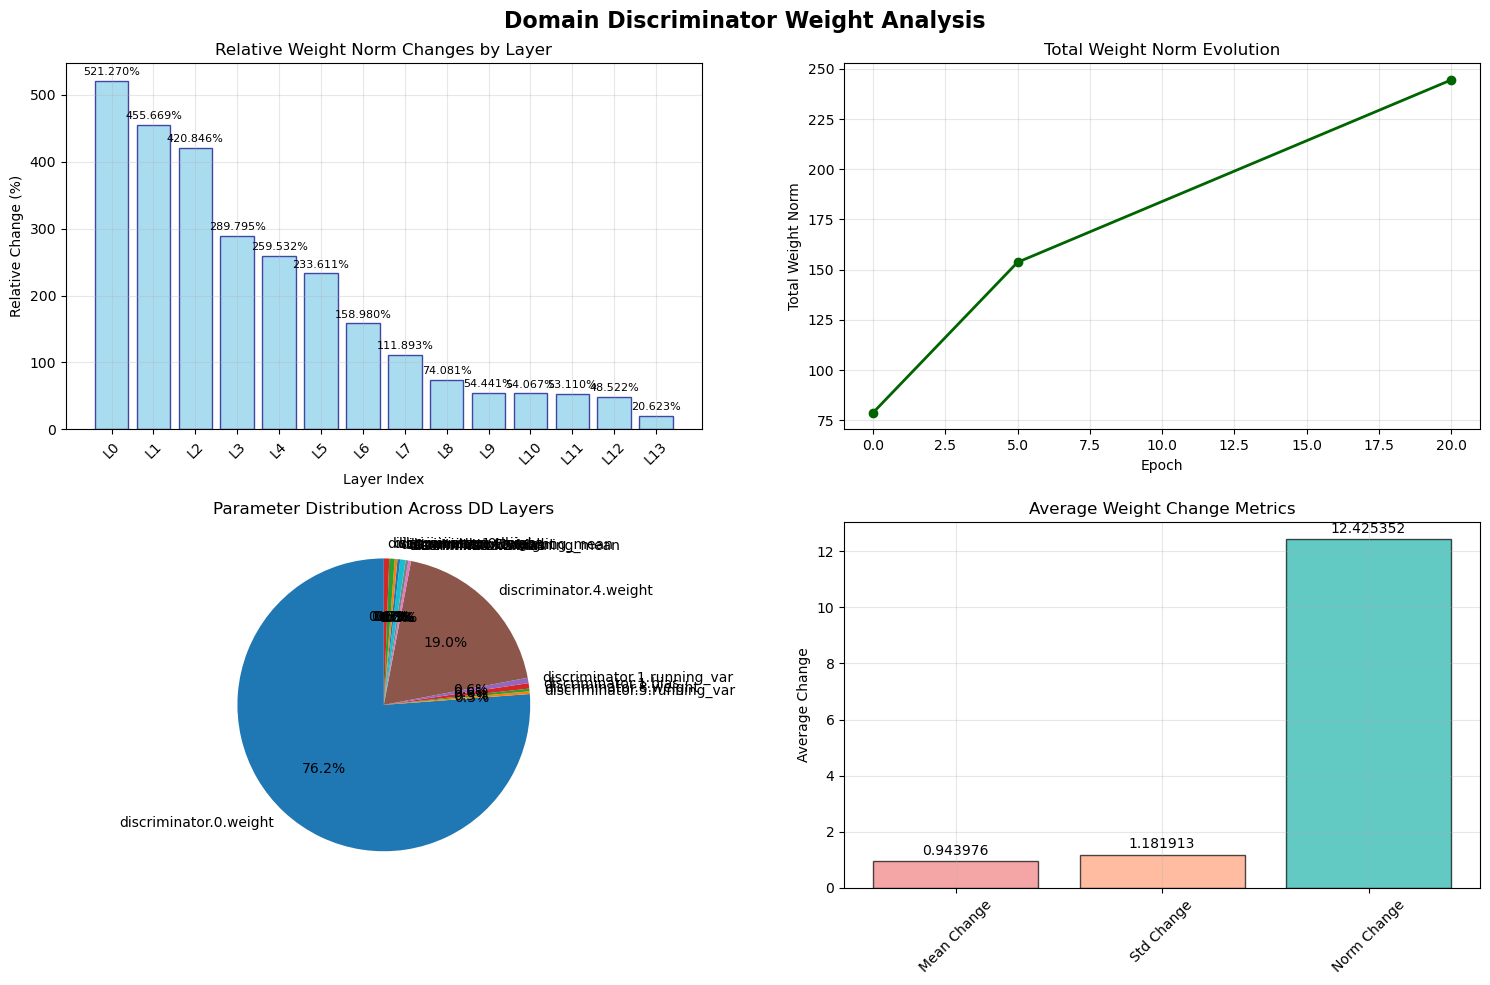

Analysis plots saved to: ../experiments/numu/da_numu_251108_middle_constlambda_aug/dd_weights_analysis.png


In [7]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Domain Discriminator Weight Analysis', fontsize=16, fontweight='bold')

# Plot 1: Relative norm changes by layer
ax1 = axes[0, 0]
layers = df_changes['Layer']
changes = df_changes['Relative Norm Change (%)']
bars = ax1.bar(range(len(layers)), changes, alpha=0.7, color='skyblue', edgecolor='navy')
ax1.set_title('Relative Weight Norm Changes by Layer')
ax1.set_xlabel('Layer Index')
ax1.set_ylabel('Relative Change (%)')
ax1.set_xticks(range(len(layers)))
ax1.set_xticklabels([f'L{i}' for i in range(len(layers))], rotation=45)
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(changes)*0.01,
             f'{height:.3f}%', ha='center', va='bottom', fontsize=8)

# Plot 2: Weight norm evolution across checkpoints
ax2 = axes[0, 1]
epochs = [checkpoint_data[cp]['epoch'] for cp in checkpoint_names if cp != 'best_da_model.pth']
# Calculate total norm for each checkpoint
total_norms = []
for cp in checkpoint_names:
    if cp != 'best_da_model.pth':  # Skip best model for timeline
        stats = checkpoint_data[cp]['stats']
        total_norm = sum(s['norm'] for s in stats.values())
        total_norms.append(total_norm)

if len(epochs) > 1:
    ax2.plot(epochs, total_norms, 'o-', linewidth=2, markersize=6, color='darkgreen')
    ax2.set_title('Total Weight Norm Evolution')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Total Weight Norm')
    ax2.grid(True, alpha=0.3)

# Plot 3: Parameter count by layer
ax3 = axes[1, 0]
param_counts = df_changes['Parameters']
wedges, texts, autotexts = ax3.pie(param_counts, labels=df_changes['Layer'], autopct='%1.1f%%', startangle=90)
ax3.set_title('Parameter Distribution Across DD Layers')

# Plot 4: Weight statistics comparison
ax4 = axes[1, 1]
metrics = ['Mean Change', 'Std Change', 'Norm Change']
values = [df_changes[metric].mean() for metric in metrics]
colors = ['lightcoral', 'lightsalmon', 'lightseagreen']
bars = ax4.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
ax4.set_title('Average Weight Change Metrics')
ax4.set_ylabel('Average Change')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# Add value labels
for bar, value in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(values)*0.01,
             f'{value:.6f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'dd_weights_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Analysis plots saved to: {EXPERIMENT_DIR / 'dd_weights_analysis.png'}")

## 6. Detailed Layer-by-Layer Analysis

In [8]:
# Detailed analysis of each layer
print("=== Detailed Layer Analysis ===\n")

for idx, row in df_changes.iterrows():
    layer_name = row['Layer']
    print(f"Layer: {layer_name}")
    print(f"  Shape: {row['Shape']}")
    print(f"  Parameters: {row['Parameters']:,}")
    print(f"  Relative norm change: {row['Relative Norm Change (%)']:.6f}%")
    
    # Get first and last stats for this layer
    first_stats = first_data['stats'][layer_name]
    last_stats = last_data['stats'][layer_name]
    
    print(f"  Weight statistics:")
    print(f"    Mean: {first_stats['mean']:.6f} → {last_stats['mean']:.6f} (Δ{last_stats['mean']-first_stats['mean']:.6f})")
    print(f"    Std:  {first_stats['std']:.6f} → {last_stats['std']:.6f} (Δ{last_stats['std']-first_stats['std']:.6f})")
    print(f"    Norm: {first_stats['norm']:.6f} → {last_stats['norm']:.6f} (Δ{last_stats['norm']-first_stats['norm']:.6f})")
    print("")

# Check if any layers have suspiciously small changes
frozen_threshold = 1e-6  # Very small change threshold
potentially_frozen = df_changes[df_changes['Relative Norm Change (%)'] < frozen_threshold * 100]

if len(potentially_frozen) > 0:
    print(f"⚠️  WARNING: {len(potentially_frozen)} layers have very small changes (< {frozen_threshold*100:.4f}%):")
    for _, row in potentially_frozen.iterrows():
        print(f"  - {row['Layer']}: {row['Relative Norm Change (%)']:.8f}%")
    print("\nThis might indicate frozen weights or convergence.")
else:
    print("✅ All layers show meaningful weight updates.")

=== Detailed Layer Analysis ===

Layer: discriminator.0.weight
  Shape: (64, 128)
  Parameters: 8,192
  Relative norm change: 521.269534%
  Weight statistics:
    Mean: 0.000117 → -0.005461 (Δ-0.005578)
    Std:  0.080124 → 0.497756 (Δ0.417632)
    Norm: 7.251549 → 45.051666 (Δ37.800117)

Layer: discriminator.5.running_var
  Shape: (32,)
  Parameters: 32
  Relative norm change: 455.669473%
  Weight statistics:
    Mean: 1.538211 → 6.574536 (Δ5.036325)
    Std:  1.216130 → 8.744218 (Δ7.528088)
    Norm: 11.025566 → 61.265705 (Δ50.240139)

Layer: discriminator.8.weight
  Shape: (1, 32)
  Parameters: 32
  Relative norm change: 420.846022%
  Weight statistics:
    Mean: -0.000240 → 0.075568 (Δ0.075808)
    Std:  0.061250 → 0.309645 (Δ0.248395)
    Norm: 0.341029 → 1.776237 (Δ1.435208)

Layer: discriminator.1.bias
  Shape: (64,)
  Parameters: 64
  Relative norm change: 289.794780%
  Weight statistics:
    Mean: -0.065238 → -0.338420 (Δ-0.273182)
    Std:  0.123415 → 0.425171 (Δ0.301755)
   

## 7. Compare with Base Model (Optional)

Check if base model weights changed as well (they should for domain adaptation).

In [9]:
# Load base model weights for comparison
def load_base_model_weights(checkpoint_path):
    """Load base model weights from checkpoint."""
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    base_state_dict = checkpoint['base_model_state_dict']
    return base_state_dict

print("Comparing base model weights (feature extractor + classifier)...\n")

# Load base model weights from first and last checkpoints
first_base_weights = load_base_model_weights(first_data['path'])
last_base_weights = load_base_model_weights(last_data['path'])

# Compute statistics
first_base_stats = compute_weight_statistics(first_base_weights)
last_base_stats = compute_weight_statistics(last_base_weights)

# Compare changes
base_weight_changes = compare_weight_changes(
    first_base_stats, last_base_stats, 
    first_checkpoint, last_checkpoint
)

# Summary statistics
base_total_norm_change = sum(c['relative_norm_change'] for c in base_weight_changes.values()) * 100
base_max_change = max(c['relative_norm_change'] for c in base_weight_changes.values()) * 100

dd_total_norm_change = df_changes['Relative Norm Change (%)'].sum()
dd_max_change = df_changes['Relative Norm Change (%)'].max()

print(f"=== Base Model vs Domain Discriminator Weight Changes ===\n")
print(f"Base Model (Feature Extractor + Classifier):")
print(f"  Total layers: {len(base_weight_changes)}")
print(f"  Total relative norm change: {base_total_norm_change:.4f}%")
print(f"  Max layer change: {base_max_change:.4f}%")

print(f"\nDomain Discriminator:")
print(f"  Total layers: {len(weight_changes)}")
print(f"  Total relative norm change: {dd_total_norm_change:.4f}%")
print(f"  Max layer change: {dd_max_change:.4f}%")

print(f"\n=== Training Assessment ===\n")

if dd_max_change > 0.1 and base_max_change > 0.1:
    print("✅ EXCELLENT: Both DD and base model weights are updating significantly.")
    print("   Domain adaptation training is working properly.")
elif dd_max_change > 0.01 and base_max_change > 0.01:
    print("✅ GOOD: Both DD and base model weights are updating moderately.")
    print("   Training appears to be working, possibly converged.")
elif dd_max_change < 0.001:
    print("❌ PROBLEM: Domain Discriminator weights barely changed!")
    print("   Check if DD optimizer is working and gradients are flowing.")
elif base_max_change < 0.001:
    print("❌ PROBLEM: Base model weights barely changed!")
    print("   Check if feature extractor and classifier optimizers are working.")
else:
    print("⚠️  MIXED: Some components updating more than others.")
    print("   This might be normal depending on training stage.")

# Ratio analysis
if dd_total_norm_change > 0 and base_total_norm_change > 0:
    ratio = dd_total_norm_change / base_total_norm_change
    print(f"\nDD to Base Model change ratio: {ratio:.3f}")
    if ratio > 2.0:
        print("  → DD is changing much more than base model (expected early in training)")
    elif ratio > 0.5:
        print("  → DD and base model changing at similar rates (balanced adaptation)")
    else:
        print("  → Base model changing more than DD (expected later in training)")

Comparing base model weights (feature extractor + classifier)...

=== Base Model vs Domain Discriminator Weight Changes ===

Base Model (Feature Extractor + Classifier):
  Total layers: 68
  Total relative norm change: 14300.5904%
  Max layer change: 1218.2109%

Domain Discriminator:
  Total layers: 14
  Total relative norm change: 2756.4397%
  Max layer change: 521.2695%

=== Training Assessment ===

✅ EXCELLENT: Both DD and base model weights are updating significantly.
   Domain adaptation training is working properly.

DD to Base Model change ratio: 0.193
  → Base model changing more than DD (expected later in training)


## 8. Summary and Recommendations

In [ ]:
print("=" * 60)
print("                    FINAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nExperiment: {EXPERIMENT_DIR.name}")
print(f"Epochs analyzed: {first_data['epoch']} → {last_data['epoch']}")
print(f"Checkpoints compared: {len(selected_checkpoints)}")

print(f"\nDomain Discriminator Analysis:")
print(f"  • Total parameters: {df_changes['Parameters'].sum():,}")
print(f"  • Layers analyzed: {len(df_changes)}")
print(f"  • Max weight change: {dd_max_change:.6f}%")
print(f"  • Total norm change: {dd_total_norm_change:.6f}%")

if 'base_total_norm_change' in locals():
    print(f"\nBase Model Analysis:")
    print(f"  • Layers analyzed: {len(base_weight_changes)}")
    print(f"  • Max weight change: {base_max_change:.6f}%")
    print(f"  • Total norm change: {base_total_norm_change:.6f}%")

# Final verdict
print(f"\n{'=' * 20} VERDICT {'=' * 20}")

if dd_max_change > 0.1:
    print("\n🎯 SUCCESS: Domain Discriminator weights ARE updating!")
    print("\n✅ Your DA training is working correctly.")
    print("\n📈 Recommendations:")
    print("   • Continue training as planned")
    print("   • Monitor domain discrimination metrics")
    print("   • Check that domain accuracy approaches 50% (random)")
    
elif dd_max_change > 0.01:
    print("\n⚠️  CAUTION: Domain Discriminator weights are updating slowly.")
    print("\n🤔 This could be normal if:")
    print("   • Training has converged")
    print("   • Learning rates are very small")
    print("   • Model is in fine-tuning phase")
    print("\n📋 Check:")
    print("   • Learning rate schedules")
    print("   • Training loss curves")
    print("   • Domain adaptation metrics")
    
else:
    print("\n❌ PROBLEM: Domain Discriminator weights are barely changing!")
    print("\n🚨 Potential issues:")
    print("   • DD optimizer not working")
    print("   • Gradients not flowing to DD")
    print("   • Lambda factor is 0 (no domain loss)")
    print("   • DD learning rate too small")
    print("\n🔧 Debug steps:")
    print("   • Check optimizer states in checkpoint")
    print("   • Verify gradient flow with grad hooks")
    print("   • Monitor lambda factor during training")
    print("   • Increase DD learning rate")

print(f"\n{'=' * 60}")
print(f"Analysis complete! Results saved to: {EXPERIMENT_DIR}")